# Matplotlib - visualizations with Python

Please read through the following sections for a very brief overview if you are unfamiliar with the Python package [_matplotlib_](https://matplotlib.org/); for an in-depth overview see the [matplotlib user guide](https://matplotlib.org/stable/users/index.html) and [tutorials](https://matplotlib.org/stable/tutorials/index.html).

## Library imports

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Matplotlib basics

[matplotlib](https://matplotlib.org/) is a Python package for generating plots: it is extremely customizable, but, for this reason, requires the user to specify multiple aspects of the figure for each plot - the reason why it is more _verbose_ than plotting packages in R or in other Python packages such as [seaborn](https://seaborn.pydata.org/index.html).

Every time you generate a plot with matplotlib, you will start by specifying the overall plot structure (`matplotlib.pyplot.subplots`) to generate two components: a _figure_ - the top level container for all the plot elements - and one or more _axes_ - the object encapsulating all the elements of an individual (sub-)plot in a figure. Defining the structure includes setting the number of rows (`nrows`) and columns (`ncols`) which itself define the number of axes based on the shape of the defined grid. Each axis can then have its own plot; i.e., you can call each one spearately with a specific plotting function. The following schematic demonstrates the structure of a figure with 4 axes arranged in a 2x2 grid.

<img src="https://matplotlib.org/stable/_images/users-explain-axes-axes_intro-1.2x.png" alt="genescore" width="600">

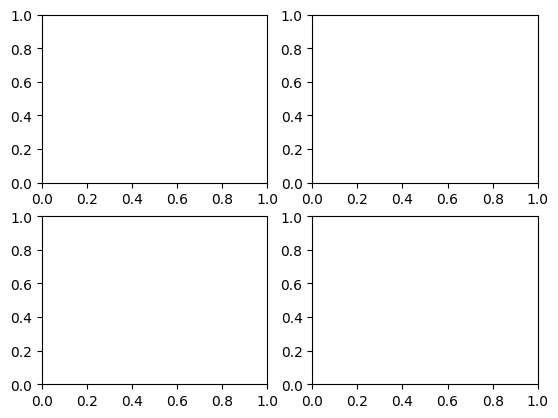

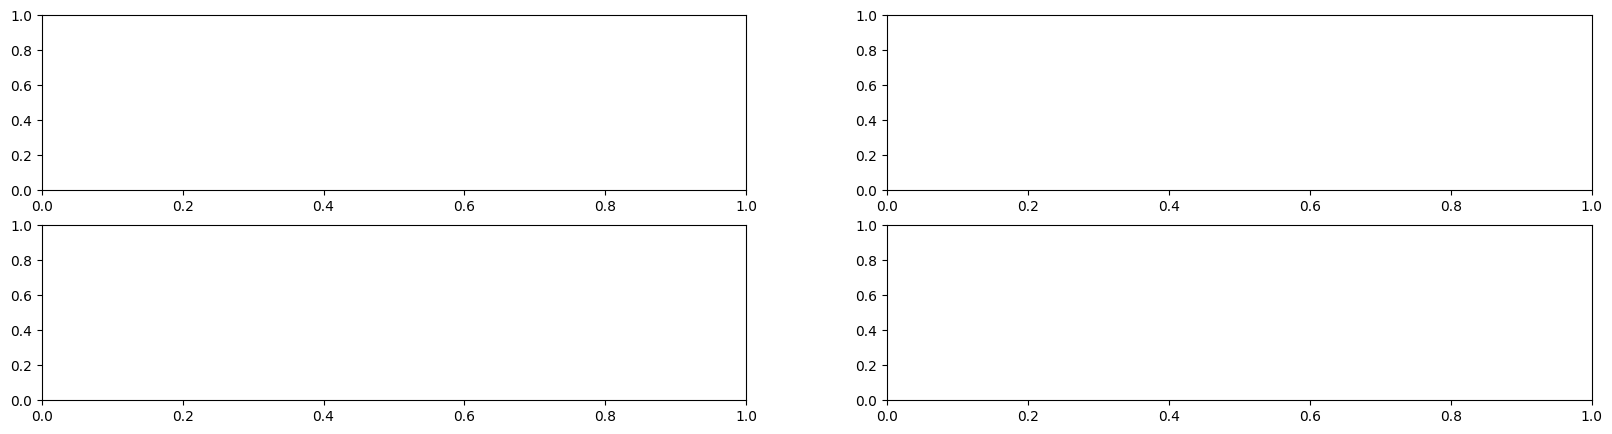

In [2]:
fig, axes = plt.subplots(nrows=2, ncols=2)  # set up plotting
plt.show()  # display figure

# specify the size of the figure to generate with the `figsize` parameter
fig, axes = plt.subplots(2, 2, figsize=(20, 5))
plt.show()

### Plot flavors - Matplotlib

Following the figure setup, we fill the axes with our desired plots by, generally speaking, calling `ax.PLOTTING_FUNCTION`, where `PLOTTING_FUNCTION` is our function of interest such as plot (line plot), scatter, or bar, for example, as demonstrated below.

In [3]:
df = pd.DataFrame(
    [
        ["Joe", 20, 85.1, "A", "swimming"],
        ["Nat", 21, 77.8, "B", "reading"],
        ["Harry", 19, 91.54, "A", "nusic"],
        ["Sam", 20, 88.87, "A", "painting"],
        ["Monica", 22, 60.55, "B", "dancing"],
    ],
    index=[f"student_{student_id}" for student_id in range(5)],
    columns=["name", "age", "marks", "grade", "hobby"],
)

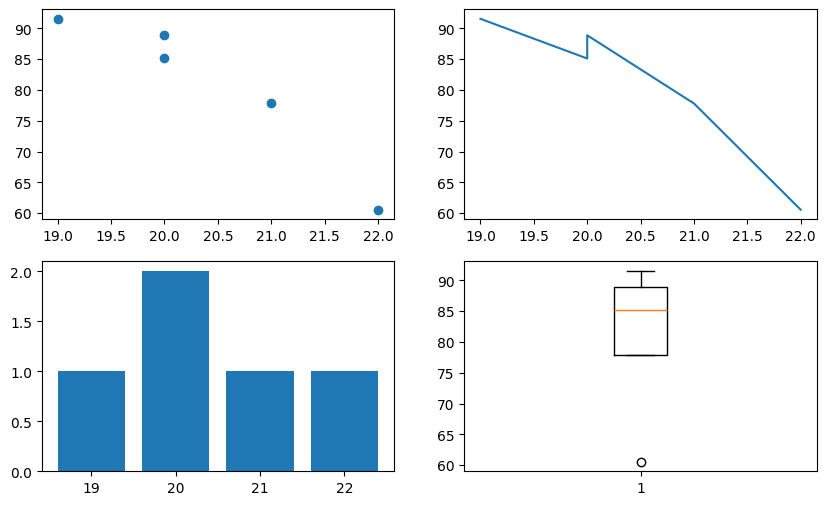

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

# Trend between age and marks as a scatter plot
axes[0, 0].scatter(x=df.loc[:, "age"], y=df.loc[:, "marks"])

# Trend between age and marks as a line plot
df_sorted = df.sort_values("age")  # x values need to be sorted
axes[0, 1].plot(df_sorted.loc[:, "age"], df_sorted.loc[:, "marks"])


# Number of students of each age
age_counts = df.value_counts("age").sort_index()
axes[1, 0].bar(x=range(age_counts.shape[0]), height=age_counts)
axes[1, 0].set_xticks(range(age_counts.shape[0]))  # Set the tick marks at the x positions specified
axes[1, 0].set_xticklabels(age_counts.index)  # Set the labels to the ages, defining the rows

# Distributions of marks as boxplot
axes[1, 1].boxplot(df["marks"])

plt.show()

### Plot flavors - Seaborn

[Seaborn](https://seaborn.pydata.org/index.html) is another useful plotting package that integrates with matplotlib and pandas to easily visualize trends in a DataFrames. Generally, you can pass a matplotlib axis object to a seaborn function, and it will fill that axis with the corresponding plot.

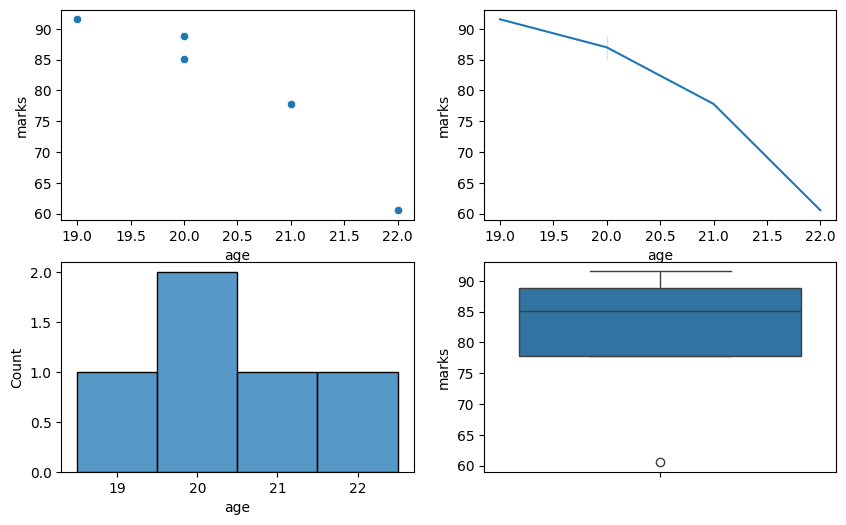

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

# Trend between age and marks as a scatter plot
sns.scatterplot(data=df, x="age", y="marks", ax=axes[0, 0])

# Trend between age and marks as a line plot
sns.lineplot(data=df, x="age", y="marks", ax=axes[0, 1])

# Number of students of each age
sns.histplot(data=df, x="age", discrete=True, ax=axes[1, 0])

# Distributions of marks as boxplot
sns.boxplot(data=df, y="marks", ax=axes[1, 1])

plt.show()